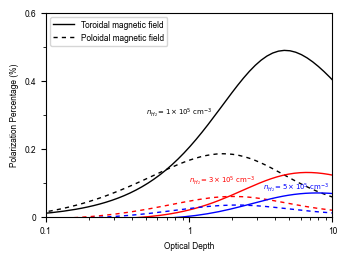

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

font = {'size'   : 6}
mpl.rc('font', **font)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

# ---- helper to load data ----
def load_xy(filename, xcol, ycol, invert_y=False):
    def clean(x):
        return float(x.replace('%', ''))  # <-- FIXED

    data = np.genfromtxt(
        filename,
        converters={i: clean for i in range(20)}
    )

    x = data[:, xcol]
    y = data[:, ycol]

    if invert_y:
        y = -y

    return x, y

# ---- files ----
files = {
    "1e5_1D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][1D][1.00e+05][0.4PI][70K][2.725K]co.dat",
    "1e5_2D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][2D][1.00e+05][0.4PI][70K][2.725K]co.dat",
    "3e5_1D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][1D][3.00e+05][0.4PI][70K][2.725K]co.dat",
    "3e5_2D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][2D][3.00e+05][0.4PI][70K][2.725K]co.dat",
    "5e5_1D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][1D][5.00e+05][0.4PI][70K][2.725K]co.dat",
    "5e5_2D": "/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/alma4Apaper/writing_MaxEq/decisions/peereview1/simulations/Louis's code/c3.6[4][2D][5.00e+05][0.4PI][70K][2.725K]co.dat",
}

# ---- plotting ----
fig=plt.figure(figsize=(3.45,3.45*4.8/6.4))

# 1e5 (black)
x, y = load_xy(files["1e5_1D"], 5, 6)
plt.plot(x, y, color="black", linewidth=1, linestyle="-", label="Toroidal magnetic field")

x, y = load_xy(files["1e5_2D"], 5, 6, invert_y=True)
plt.plot(x, y, color="black", linewidth=1, linestyle=(0, (3, 3)), label="Poloidal magnetic field")

# 3e5 (red)
x, y = load_xy(files["3e5_1D"], 5, 6)
plt.plot(x, y, color="red", linewidth=1)

x, y = load_xy(files["3e5_2D"], 5, 6, invert_y=True)
plt.plot(x, y, color="red", linewidth=1, linestyle=(0, (3, 3)))

# 5e5 (blue)
x, y = load_xy(files["5e5_1D"], 5, 6)
plt.plot(x, y, color="blue", linewidth=1)

x, y = load_xy(files["5e5_2D"], 5, 6, invert_y=True)
plt.plot(x, y, color="blue", linewidth=1, linestyle=(0, (3, 3)))

# ---- axes ----
plt.xscale("log")
plt.xlim(0.1, 10)
plt.xticks([0.1,1,10], ["0.1", "1", "10"])

plt.ylim(0, -0.6)
plt.yticks([0, -0.2, -0.4, -0.6], ["0", "0.2", "0.4", "0.6"])
ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.xlabel("Optical Depth")
plt.ylabel("Polarization Percentage (%)")

# ---- legend ----
plt.legend(loc="upper left", frameon=True, handlelength=2.5)

# ---- annotations ----
plt.text(0.5, -0.3, r"$n_{H_2} = 1 \times 10^{5}\ \mathrm{cm^{-3}}$", color="black",size=5)
plt.text(1.0, -0.1, r"$n_{H_2} = 3 \times 10^{5}\ \mathrm{cm^{-3}}$", color="red",size=5)
plt.text(3.3, -0.08, r"$n_{H_2} = 5 \times 10^{5}\ \mathrm{cm^{-3}}$", color="blue",size=5)

# ---- output ----
plt.tight_layout()
plt.savefig("alma_iras4a_nc_70K_1D_2D.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

In [5]:
width_in, height_in = fig.get_size_inches()

width_mm = width_in * 25.4
height_mm = height_in * 25.4

print(width_mm, height_mm)
print(mpl.rcParams['font.family'])
print(mpl.rcParams['font.sans-serif'])

87.63 65.72249999999998
['sans-serif']
['Arial']


In [31]:
import pyperclip

x, y = load_xy(files["1e5_1D"], 5, 6)

#x, y = load_xy(files["1e5_2D"], 5, 6, invert_y=True)

# 3e5 (red)
#x, y = load_xy(files["3e5_1D"], 5, 6)

#x, y = load_xy(files["3e5_2D"], 5, 6, invert_y=True)

# 5e5 (blue)
#x, y = load_xy(files["5e5_1D"], 5, 6)

#x, y = load_xy(files["5e5_2D"], 5, 6, invert_y=True)

#print(*(x), sep='\n')
tmpx = x.flatten()
output_text = "\n".join(map(str, tmpx))
print(output_text, sep='\n')
pyperclip.copy(output_text)


0.0058508235472
0.0064242983015
0.007054390915
0.0077467461799
0.0085075788887
0.0093437321898
0.010262742063
0.011272908388
0.012383378408
0.013604216193
0.014946522601
0.016422526071
0.018045703105
0.019830907395
0.021794512527
0.023954568998
0.026330979068
0.028945687778
0.031822895789
0.034989292617
0.038474315663
0.042310434833
0.046533467088
0.051182923195
0.056302390028
0.061939952226
0.068148655389
0.074987079907
0.082519675417
0.09081771465
0.099959686289
0.11003226449
0.12113095431
0.1333610766
0.14683873365
0.16169189001
0.17806154937
0.1961030425
0.21598742683
0.2379030289
0.26205745442
0.28867809552
0.31801592033
0.35034646717
0.38597242001
0.42522610799
0.46847217957
0.51611055498
0.56857950333
0.62635904607
0.6899745671
0.76000243604
0.8370678083
0.92185800496
1.0151217711
1.1176757436
1.2304099991
1.3542940158
1.490383092
1.6398296027
1.8038744289
1.9838775975
2.1813129378
2.3977810878
2.6350198678
2.8949168
3.1795200699
3.4910546717
3.8319516076
4.2048126239
4.61250567

In [32]:
tmpx = (y*-1).flatten()
output_text = "\n".join(map(str, tmpx))
print(output_text, sep='\n')
pyperclip.copy(output_text)

-0.00261
-0.002635
-0.002653
-0.002662
-0.002662
-0.00265
-0.002627
-0.002589
-0.002536
-0.002465
-0.002375
-0.002262
-0.002125
-0.001959
-0.001763
-0.001533
-0.001264
-0.000952
-0.000592
-0.000179
0.000293
0.000832
0.001444
0.002138
0.002924
0.003813
0.004817
0.005948
0.007223
0.008657
0.010272
0.012088
0.014128
0.016421
0.018995
0.021885
0.025128
0.028764
0.032839
0.037403
0.042508
0.048216
0.054586
0.061687
0.069587
0.078358
0.088072
0.098803
0.110619
0.123582
0.137748
0.153155
0.169827
0.187762
0.206931
0.227265
0.248658
0.270952
0.293937
0.317347
0.340858
0.364093
0.386625
0.407994
0.427723
0.44534
0.460411
0.472564
0.481515
0.487104
0.489288
0.488155
0.483901
0.476812
0.467225
0.455501
0.44199
0.427015
0.410862
0.393775
0.375979
0.357662
0.338997
0.320148
0.301269
0.282506
0.264002
0.245878
0.228256
0.211242
0.194927
0.179386
0.164679
0.150846
0.137912
0.125883
0.11475
0.104491
0.095071
0.086451
0.078579
0.071406
0.06488
0.058949
0.053563
0.048676
0.044242
0.040222
0.036576
0.033